In [1]:
import os
import gc
import sys
import time

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import squidpy as sq

import pyro
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sys.path.append('../')
sys.path.append('../util')
sys.path.append('../models')

# LYNX imports
import IO, plot, utils, trajectory, metrics
import vgae, configs, dataset
from importlib import reload

[2025-04-15 19:52:36] cffi mode is CFFI_MODE.ANY
[2025-04-15 19:52:36] R home found: /usr/lib/R
[2025-04-15 19:52:36] R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/cv2/../../lib64:/usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64:/usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64
[2025-04-15 19:52:36] LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/cv2/../../lib64:/usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64:/usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64
[2025-04-15 19:52:36] Default options to initialize R: rpy2, --quiet, --no-save
[2025-04-15 19:52:36] R is already initialized. No need to initialize.


### Load Data

In [3]:
# Load paired Xenium & DESI
xenium_path = '../../liver3d_bucket/Xenium example /processed'
desi_path = '../../liver3d_bucket/DESI/processed'
sample_id = 'NIH_F5'

adata_xenium = IO.load_xenium(os.path.join(xenium_path, sample_id))
adata_desi = sc.read_h5ad(os.path.join(desi_path, sample_id+'.h5'))
adata_xenium, adata_desi = IO.filter_cells(adata_xenium, adata_desi, by='map')

/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/pandas/core/frame.py:6230: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  new_obj.index = new_index
/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
if 'cell_type' in adata_xenium.obs.keys():
    adata_xenium.obs['leiden'], categories = adata_xenium.obs.cell_type.factorize()
    categories = categories.values
else:
    adata_norm = adata_xenium.copy()
    sc.pp.normalize_total(adata_norm)
    sc.pp.log1p(adata_norm)

    sc.pp.pca(adata_norm)
    sc.pp.neighbors(adata_norm)
    sc.tl.leiden(adata_norm, random_state=42)
    adata_xenium.obs['leiden'] = adata_norm.obs['leiden'].copy()
    del adata_norm  

/var/tmp/ipykernel_119377/2696407063.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_xenium.obs['leiden'], categories = adata_xenium.obs.cell_type.factorize()


## Run Models

### Ablation study (c)

In [ ]:
# Dataset specs
n_subgraphs = 16
k = 20
r = 50
sigma = 20

graph_data = dataset.HeteroDataset(
    adatas_ref=adata_xenium, 
    adatas_query=adata_desi,
    n_subgraphs=n_subgraphs, 
    k=k,
    r=r,
    is_weighted=True,
    sigma=sigma,
    verbose=True
)

train_data, val_data = random_split(graph_data, [0.7, 0.3])
train_dl, val_dl = DataLoader(train_data, shuffle=True), DataLoader(val_data)

In [ ]:
# Model parameters
n_hidden = 32
n_latent = 6
celltype_aware = False # change this

# Training parameters
n_epochs = 400
lr = 1e-2
patience = 20

# Training & Inference
train_configs = configs.set_train_configs(
    n_epochs=n_epochs, lr=lr, patience=patience, 
    device=torch.device('cuda'),
    # scheduler step and gamma applies gamma every step
    # step_size=100, 
    gamma=0.995,
    verbose=True
)

model_configs = configs.set_model_configs(
    c_in=adata_xenium.shape[1],   # ref-dim 
    c_aux=adata_desi.shape[1],  # query-dim
    c_hidden=n_hidden, 
    c_latent=n_latent,
    act=nn.SiLU(),
    ref=graph_data.ref, 
    query=graph_data.query,
    num_clusters=graph_data.num_clusters,
    verbose=True,
    celltype_aware=celltype_aware
) 

In [ ]:
# TRAIN

pyro.clear_param_store()
torch.cuda.empty_cache()
gc.collect()

model = vgae.HeteroVGAE(model_configs, device=torch.device('cuda'))
model.fit(train_configs, train_dl=train_dl, val_dl=val_dl, DEBUG=True)

Epoch 236 train -ELBO: 171.521; val -ELBO: 169.732; val R2: 0.932; val corr: 0.504; pz corr: 0.611:  59%|▌| 237/

In [ ]:
# evaluate

# Full inference with best model params
res = model.evaluate(
    adata_xenium, adata_desi,
    graph_data=graph_data,
    device=torch.device('cpu')
)

In [ ]:
# (1). Reconstruction
rand_indices = np.random.choice(
    np.arange(adata_xenium.shape[0]*adata_xenium.shape[1]), 10000, replace=False
)
plot.disp_kde_scatter(
    adata_xenium.X.A.flatten()[rand_indices],
    res.px.flatten()[rand_indices],
    xlabel=r"Ground-truth observation",
    ylabel=r"Reconstructed observation",
    title='Xenium feature reconstruction'
)
del rand_indices
gc.collect()

In [ ]:
# (2). Latent disentanglement
plot.disp_factor_corr(res.qzu)
# plot.disp_spatial_latents(adata_xenium, res.qzx, ncols=3)

In [ ]:
# (3). Trajectory inference
# High-dim gradients (x)
trajectory.compute_trajectory(
    adata_xenium, 
    use_rep='X_z',
    n_neighbors=100,
    root_marker='DPT'
)

sq.pl.spatial_scatter(
    adata_xenium, color='t', 
    cmap='RdBu_r', size=20, img=False,
    title=r'Spatial Trajectory ($\gamma(t)$)'+'\nLYNX (Xenium)'
)

# Low-dim gradients (u)
trajectory.compute_trajectory(
    adata_desi, 
    use_rep='X_z',
    n_neighbors=100,
    root_marker='Taurine '
)

sq.pl.spatial_scatter(
    adata_desi, color='t', 
    cmap='RdBu_r', size=1, img=False,
    title=r'Spatial Trajectory ($\gamma(t)$)'+'\nLYNX (DESI)'
)

In [ ]:
utils.get_zonation_features(
    adata_xenium, adata_desi, n_zones=5, option='piecewise', sample_id=sample_id
)

In [ ]:
del adata_xenium.uns['epg']
del adata_desi.uns['epg']

adata_xenium.write_h5ad('../../results/ablation_c/aware_false/adata_xenium.h5')
adata_desi.write_h5ad('../../results/ablation_c/aware_false/adata_desi.h5')

## Metrics

### Utils

In [5]:
from statannotations.Annotator import Annotator

In [6]:
from scipy.spatial import cKDTree

def correct_mislabel_veins(adata, use_rep='ab_label', k=10):
    spatial_coords = adata.obsm["spatial"]
    labels = adata.obs[use_rep].values

    # Get indices for each label
    idx_label_1 = np.where(labels == 1)[0]
    idx_label_2 = np.where(labels == 2)[0]
    idx_label_3 = np.where(labels == 3)[0]

    # Build KD-trees for fast nearest-neighbor search
    tree_label_1 = cKDTree(spatial_coords[idx_label_1])
    tree_label_2 = cKDTree(spatial_coords[idx_label_2])

    # Find average distances from each label 3 cell to label 1 and label 2
    d1, _ = tree_label_1.query(spatial_coords[idx_label_3], k=k, workers=-1)
    d2, _ = tree_label_2.query(spatial_coords[idx_label_3], k=k, workers=-1)

    avg_d1 = d1.mean(axis=1)
    avg_d2 = d2.mean(axis=1)

    # Identify mislabeled 3s where avg distance to 1 is smaller than to 2
    mislabeled = avg_d1 < avg_d2
    labels[idx_label_3[mislabeled]] = 0  # Correct misclassified labels

    # Denoise
    labels = adata.obs[use_rep].values

    # Get indices for labels 0 & 3
    idx_label_0 = np.where(labels == 0)[0]
    idx_label_3 = np.where(labels == 3)[0]
    idx_0_3 = np.concatenate([idx_label_0, idx_label_3])  # Only process 0 & 3

    # Build KD-tree for spatial queries
    tree = cKDTree(spatial_coords)

    # Query nearest neighbors (excluding self)
    _, neighbors = tree.query(spatial_coords[idx_0_3], k=k+1, workers=-1)  # k+1 to exclude self

    # Count majority labels in neighbors
    for i, idx in enumerate(idx_0_3):
        neighbor_labels = labels[neighbors[i, 1:]]  # Exclude self
        majority_label = np.bincount(neighbor_labels).argmax()  # Most frequent label

        # Only update if the majority is different from the current label
        if majority_label in {0, 3} and majority_label != labels[idx]:
            labels[idx] = majority_label

    # Update AnnData object
    adata.obs[use_rep] = labels
    adata.obs[use_rep] = adata.obs[use_rep].astype('category')
    return None

def calculate_vein_axis(
    adata, use_rep='ab_label', 
    w1=.5, w2=.5, 
    vmin=0., vmax=1., k=10
):
    r"""Approx. annotation of PV -> CV axis from only antibody imaging"""
    # Extract spatial coordinates
    coords = adata.obsm['spatial']

    # Identify indices for each structure
    cv_indices = np.where(adata.obs[use_rep] == 0)[0]
    pp_indices = np.where(adata.obs[use_rep] == 2)[0]
    pv_indices = np.where(adata.obs[use_rep] == 3)[0]

    # Build KD-Trees for each structure
    cv_tree = cKDTree(coords[cv_indices])
    pp_tree = cKDTree(coords[pp_indices])
    pv_tree = cKDTree(coords[pv_indices])

    # Initialize array to hold PV-CV values
    axis_values = np.zeros(coords.shape[0])

    # Calculate mean distances to each structure
    for i, point in enumerate(coords):
        d_cv, _ = cv_tree.query(point, k=k)
        d_pp, _ = pp_tree.query(point, k=k)
        d_pv, _ = pv_tree.query(point, k=k)

        mu_cv = np.mean(d_cv)
        mu_pp = np.mean(d_pp)
        mu_pv = np.mean(d_pv)

        # Calculate H1(Medulla vs. Cortex) & H2 (Cortex vs. Capsule)
        H1 = (mu_pp - mu_pv) / (mu_pp + mu_pv)
        H2 = (mu_cv - mu_pp) / (mu_cv + mu_pp)

        # Combine H1 and H2 to get CMA value
        axis_values[i] = w1 * H1 + w2 * H2

    # Rescale to [vmin, vmax]
    axis_min, axis_max = np.min(axis_values), np.max(axis_values)
    axis_values = vmin + (axis_values - axis_min) * ((vmax-vmin) / (axis_max-axis_min))

    adata.obs['t'] = 1.0 - axis_values   # PV (0) --> CV (1)
    return None

### Load adata

In [7]:
adata_xenium_c = ad.read_h5ad('../../results/ablation_c/aware_true/adata_xenium.h5')
adata_xenium_nc = ad.read_h5ad('../../results/ablation_c/aware_false/adata_xenium.h5')

In [8]:
t_c = adata_xenium_c.obs['t']
t_nc = adata_xenium_nc.obs['t']

In [9]:
methods = ['with c', 'without c']
ts = ['t_c', 't_nc']

### Antibody validation

In [10]:
ab_path = '../../data/antibody'
sample_id = 'NIH_F5'

adata_ab = IO.load_ab_stain(
    os.path.join(ab_path, sample_id+'.ome.tif'),
    adata_ref=adata_xenium
)

In [11]:
# Normalize to [0, 1] per channel
scaled_chans = np.zeros_like(adata_ab.X)
for i, chan in enumerate(adata_ab.X.T):
    chan = (chan-chan.min()) / (chan.max()-chan.min())
    scaled_chans[:, i] = chan

adata_ab.X = scaled_chans

ab_dict = {
    'Opal 690-GS': 'Central Vein',
    'Opal 780-CYP3A4': 'Peri-central',
    'Opal 570-ASS1': 'Peri-portal',
    'Opal 520-Col1': 'Portal Vein'
}
ab_labels = list(ab_dict.keys())

In [12]:
# Obtain 1-hot encoded argmax
argmax_expr = adata_ab.X.argmax(1)
adata_ab.obs['ab_label'] = argmax_expr
correct_mislabel_veins(adata_ab, k=50)
calculate_vein_axis(adata_ab, k=10)

In [13]:
y_gs = (adata_ab[:, ab_labels[0]].X > metrics.get_antibody_threshold(adata_ab, ab_labels[0])).squeeze().astype(np.uint8)
y_cyp = (adata_ab[:, ab_labels[1]].X > metrics.get_antibody_threshold(adata_ab, ab_labels[1])).squeeze().astype(np.uint8)
y_ass = (adata_ab[:, ab_labels[2]].X < metrics.get_antibody_threshold(adata_ab, ab_labels[2])).squeeze().astype(np.uint8)
y_col1 = (adata_ab[:, ab_labels[3]].X < metrics.get_antibody_threshold(adata_ab, ab_labels[3])).squeeze().astype(np.uint8)

y_antibodies = [y_gs, y_cyp, y_ass, y_col1]

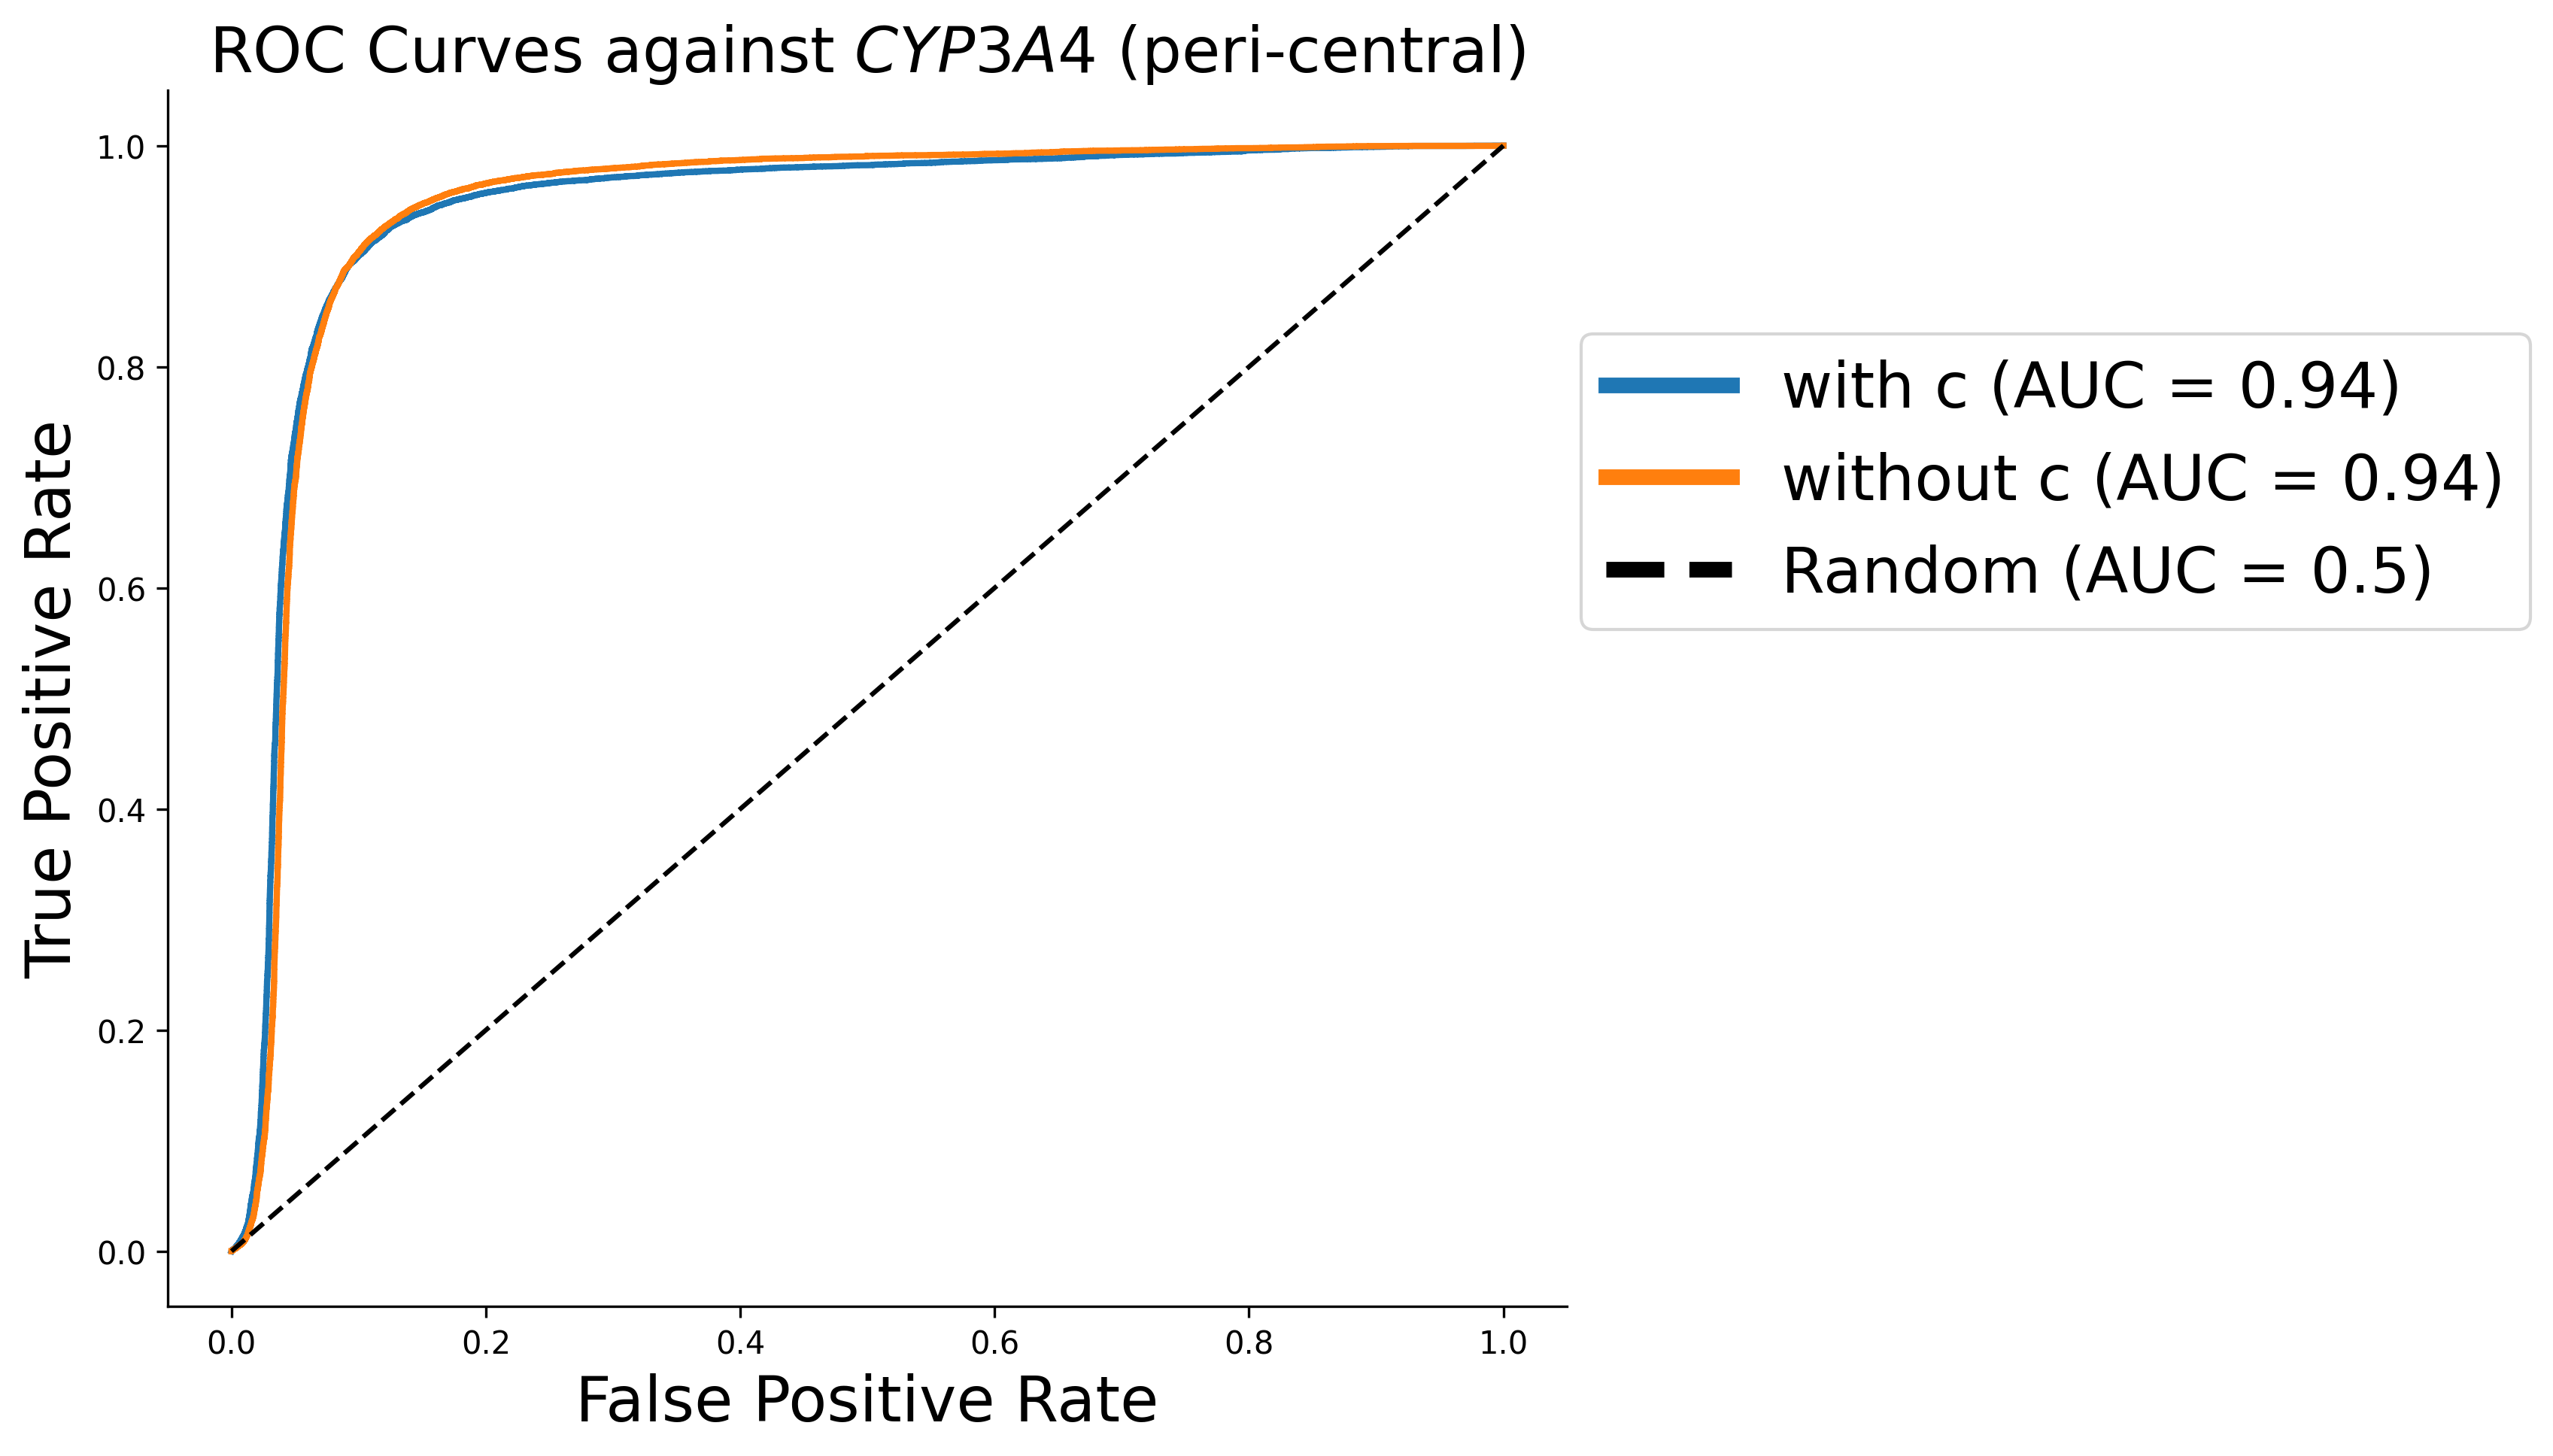

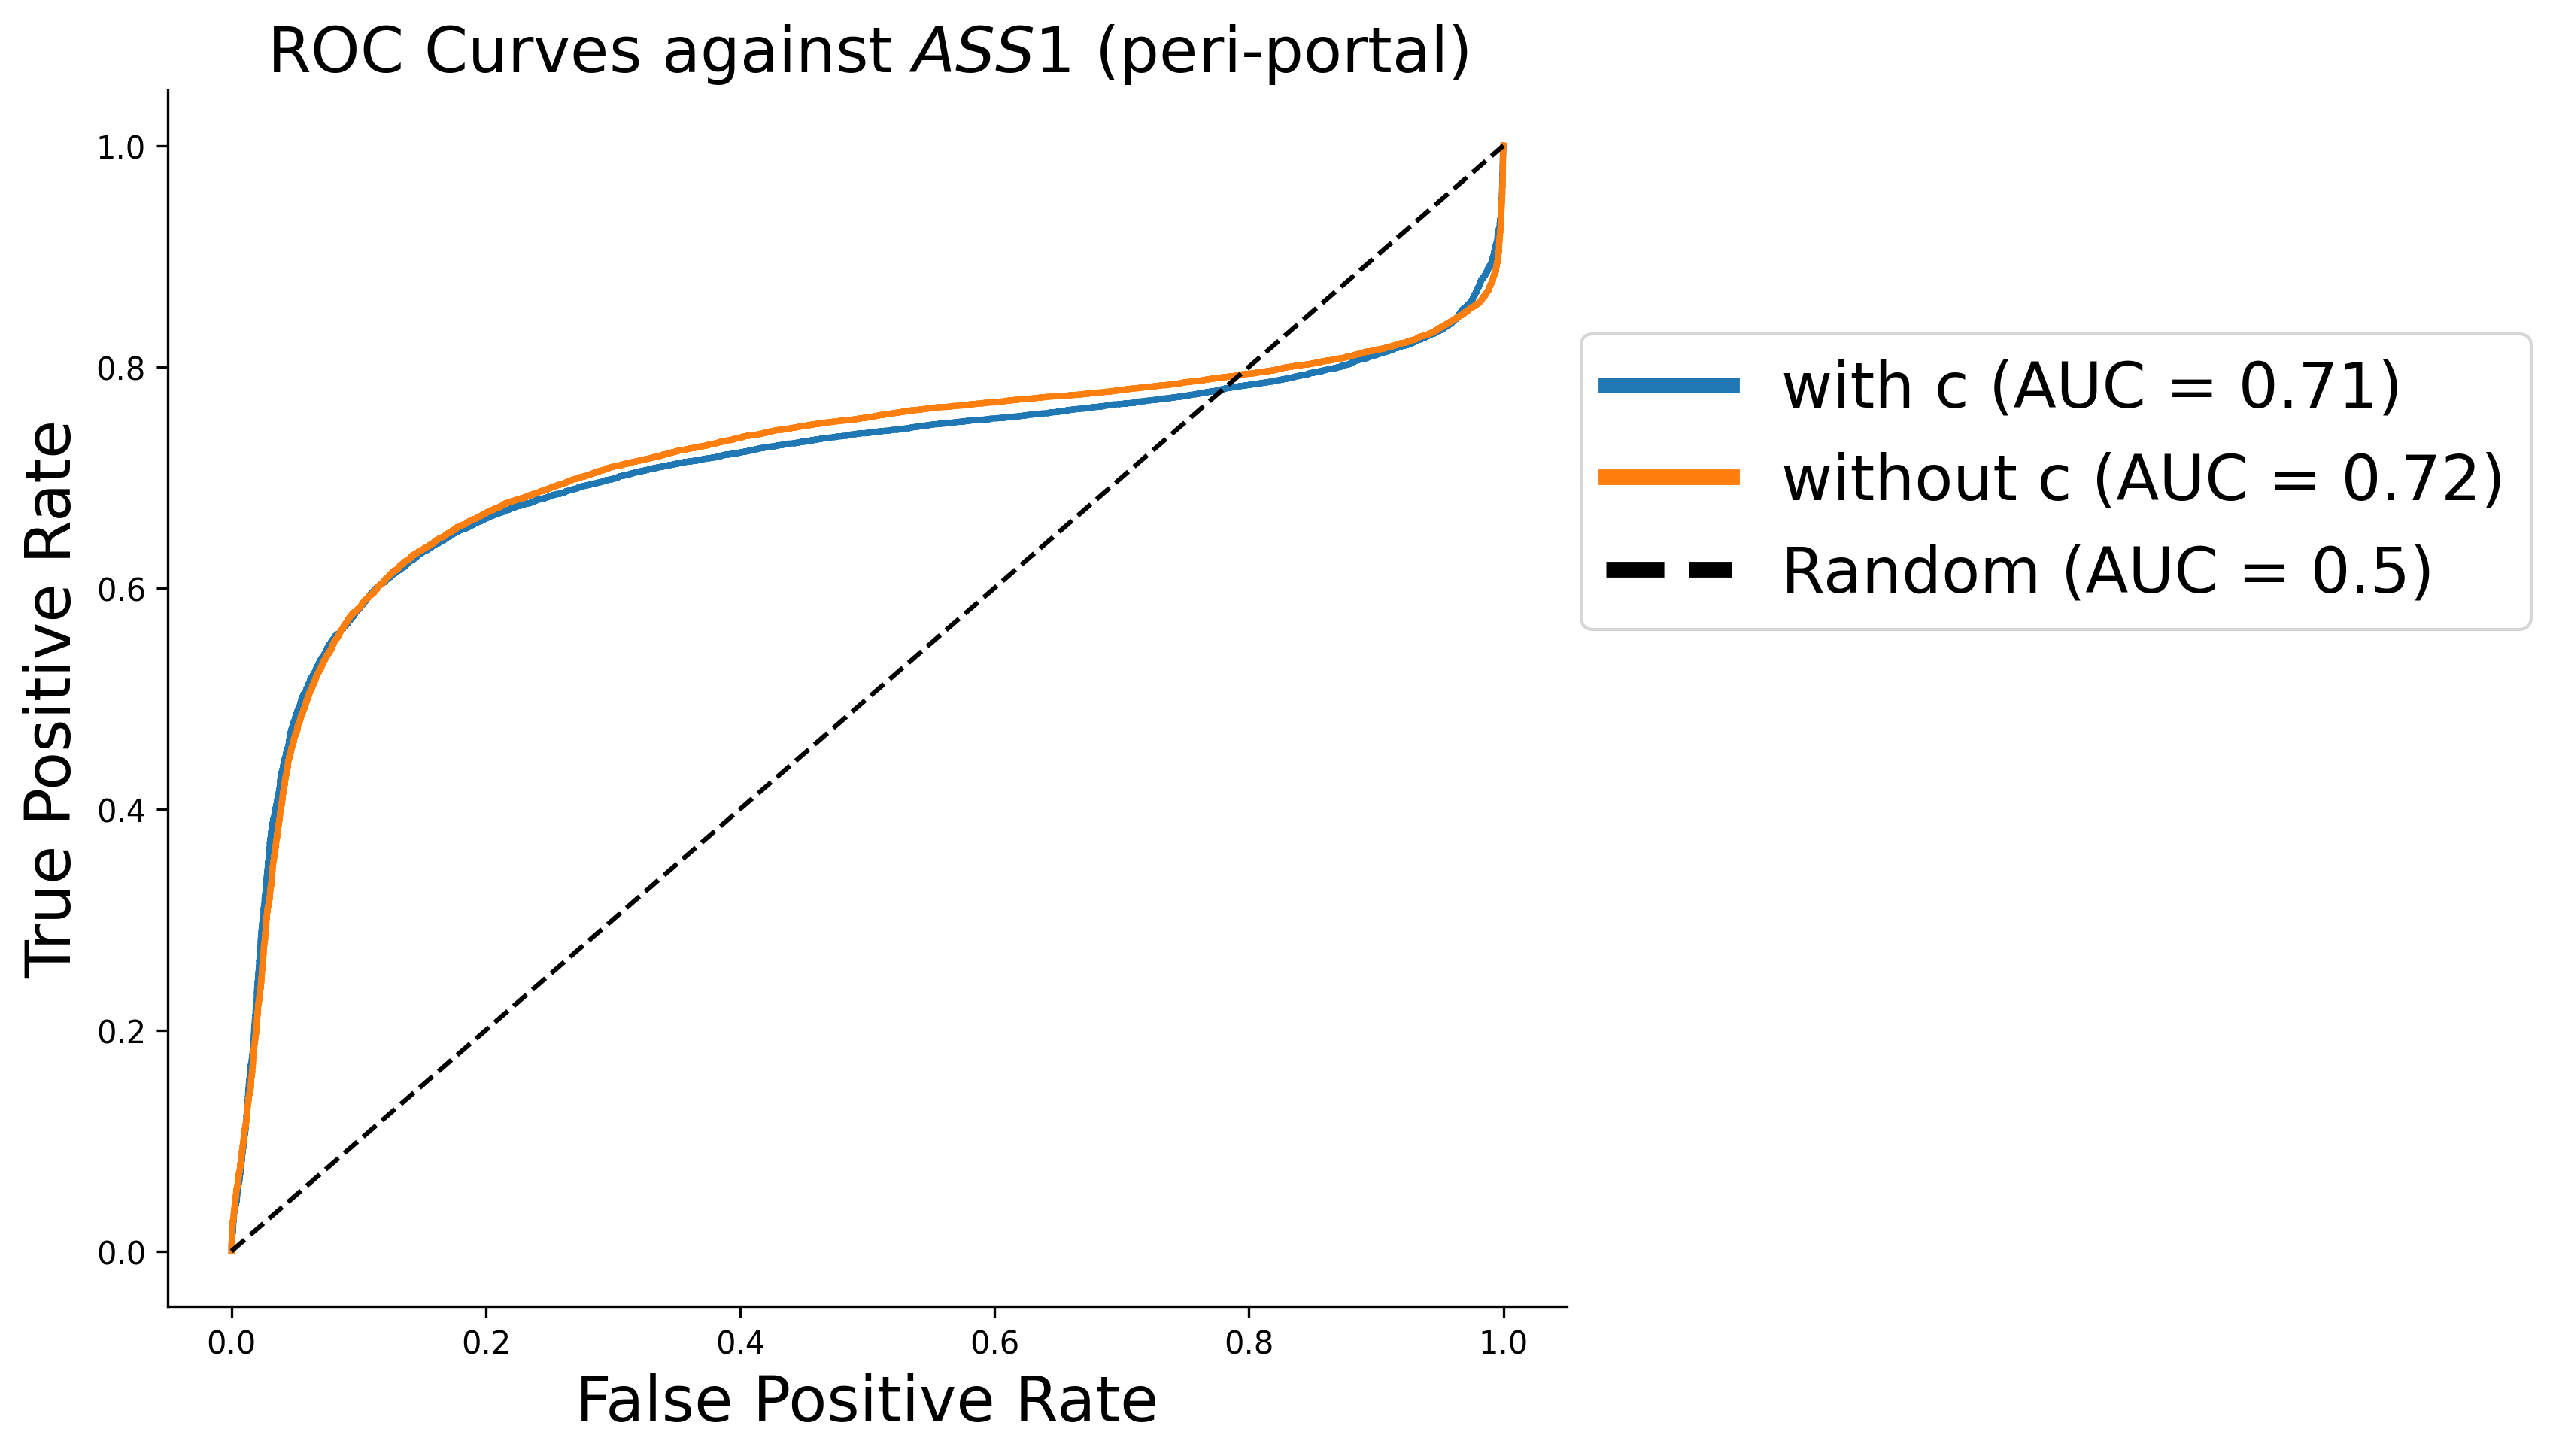

In [14]:
# ROC curves against CYP (peri-central) and ASS1 (peri-portal) channels

from sklearn.metrics import auc, roc_curve

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)
for i in range(2):
    if i == 0:
        y_pred = adata_xenium_c.obs['t'].values
        method = 'with c'
    else:
        y_pred = adata_xenium_nc.obs['t'].values
        method = 'without c'

    fpr, tpr, _ = roc_curve(y_cyp, y_pred)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{method} (AUC = {roc_auc:.2f})", lw=2)

ax.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.5)")
ax.set_xlabel('False Positive Rate', fontsize=20)
ax.set_ylabel('True Positive Rate', fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
leg = ax.legend(bbox_to_anchor=(1.01, 0.8), loc='upper left', borderaxespad=0, fontsize=20)
for line in leg.get_lines():
    line.set_linewidth(5)
ax.set_title('ROC Curves against '+r'$CYP3A4$ (peri-central)', fontsize=20)
fig.show()


fig, ax = plt.subplots(figsize=(8, 7), dpi=300)
for i in range(2):
    if i == 0:
        y_pred = adata_xenium_c.obs['t'].values
        method = 'with c'
    else:
        y_pred = adata_xenium_nc.obs['t'].values
        method = 'without c'

    fpr, tpr, _ = roc_curve(y_ass, y_pred)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{method} (AUC = {roc_auc:.2f})", lw=2)

ax.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.5)")
ax.set_xlabel('False Positive Rate', fontsize=20)
ax.set_ylabel('True Positive Rate', fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
leg = ax.legend(bbox_to_anchor=(1.01, 0.8), loc='upper left', borderaxespad=0, fontsize=20)
for line in leg.get_lines():
    line.set_linewidth(5)
ax.set_title('ROC Curves against '+r'$ASS1$ (peri-portal)', fontsize=20)
fig.show()

In [15]:
ap_c = metrics.compute_ap(adata_xenium_c.obs['t'].values, y_antibodies)
ap_nc = metrics.compute_ap(adata_xenium_nc.obs['t'].values, y_antibodies)

aps = np.array([ap_c, ap_nc])

In [16]:
ap_c

array([0.38543124, 0.84454271, 0.82210924, 0.7651478 ])

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

with c vs. without c: t-test independent samples, P_val:9.707e-01 t=3.832e-02


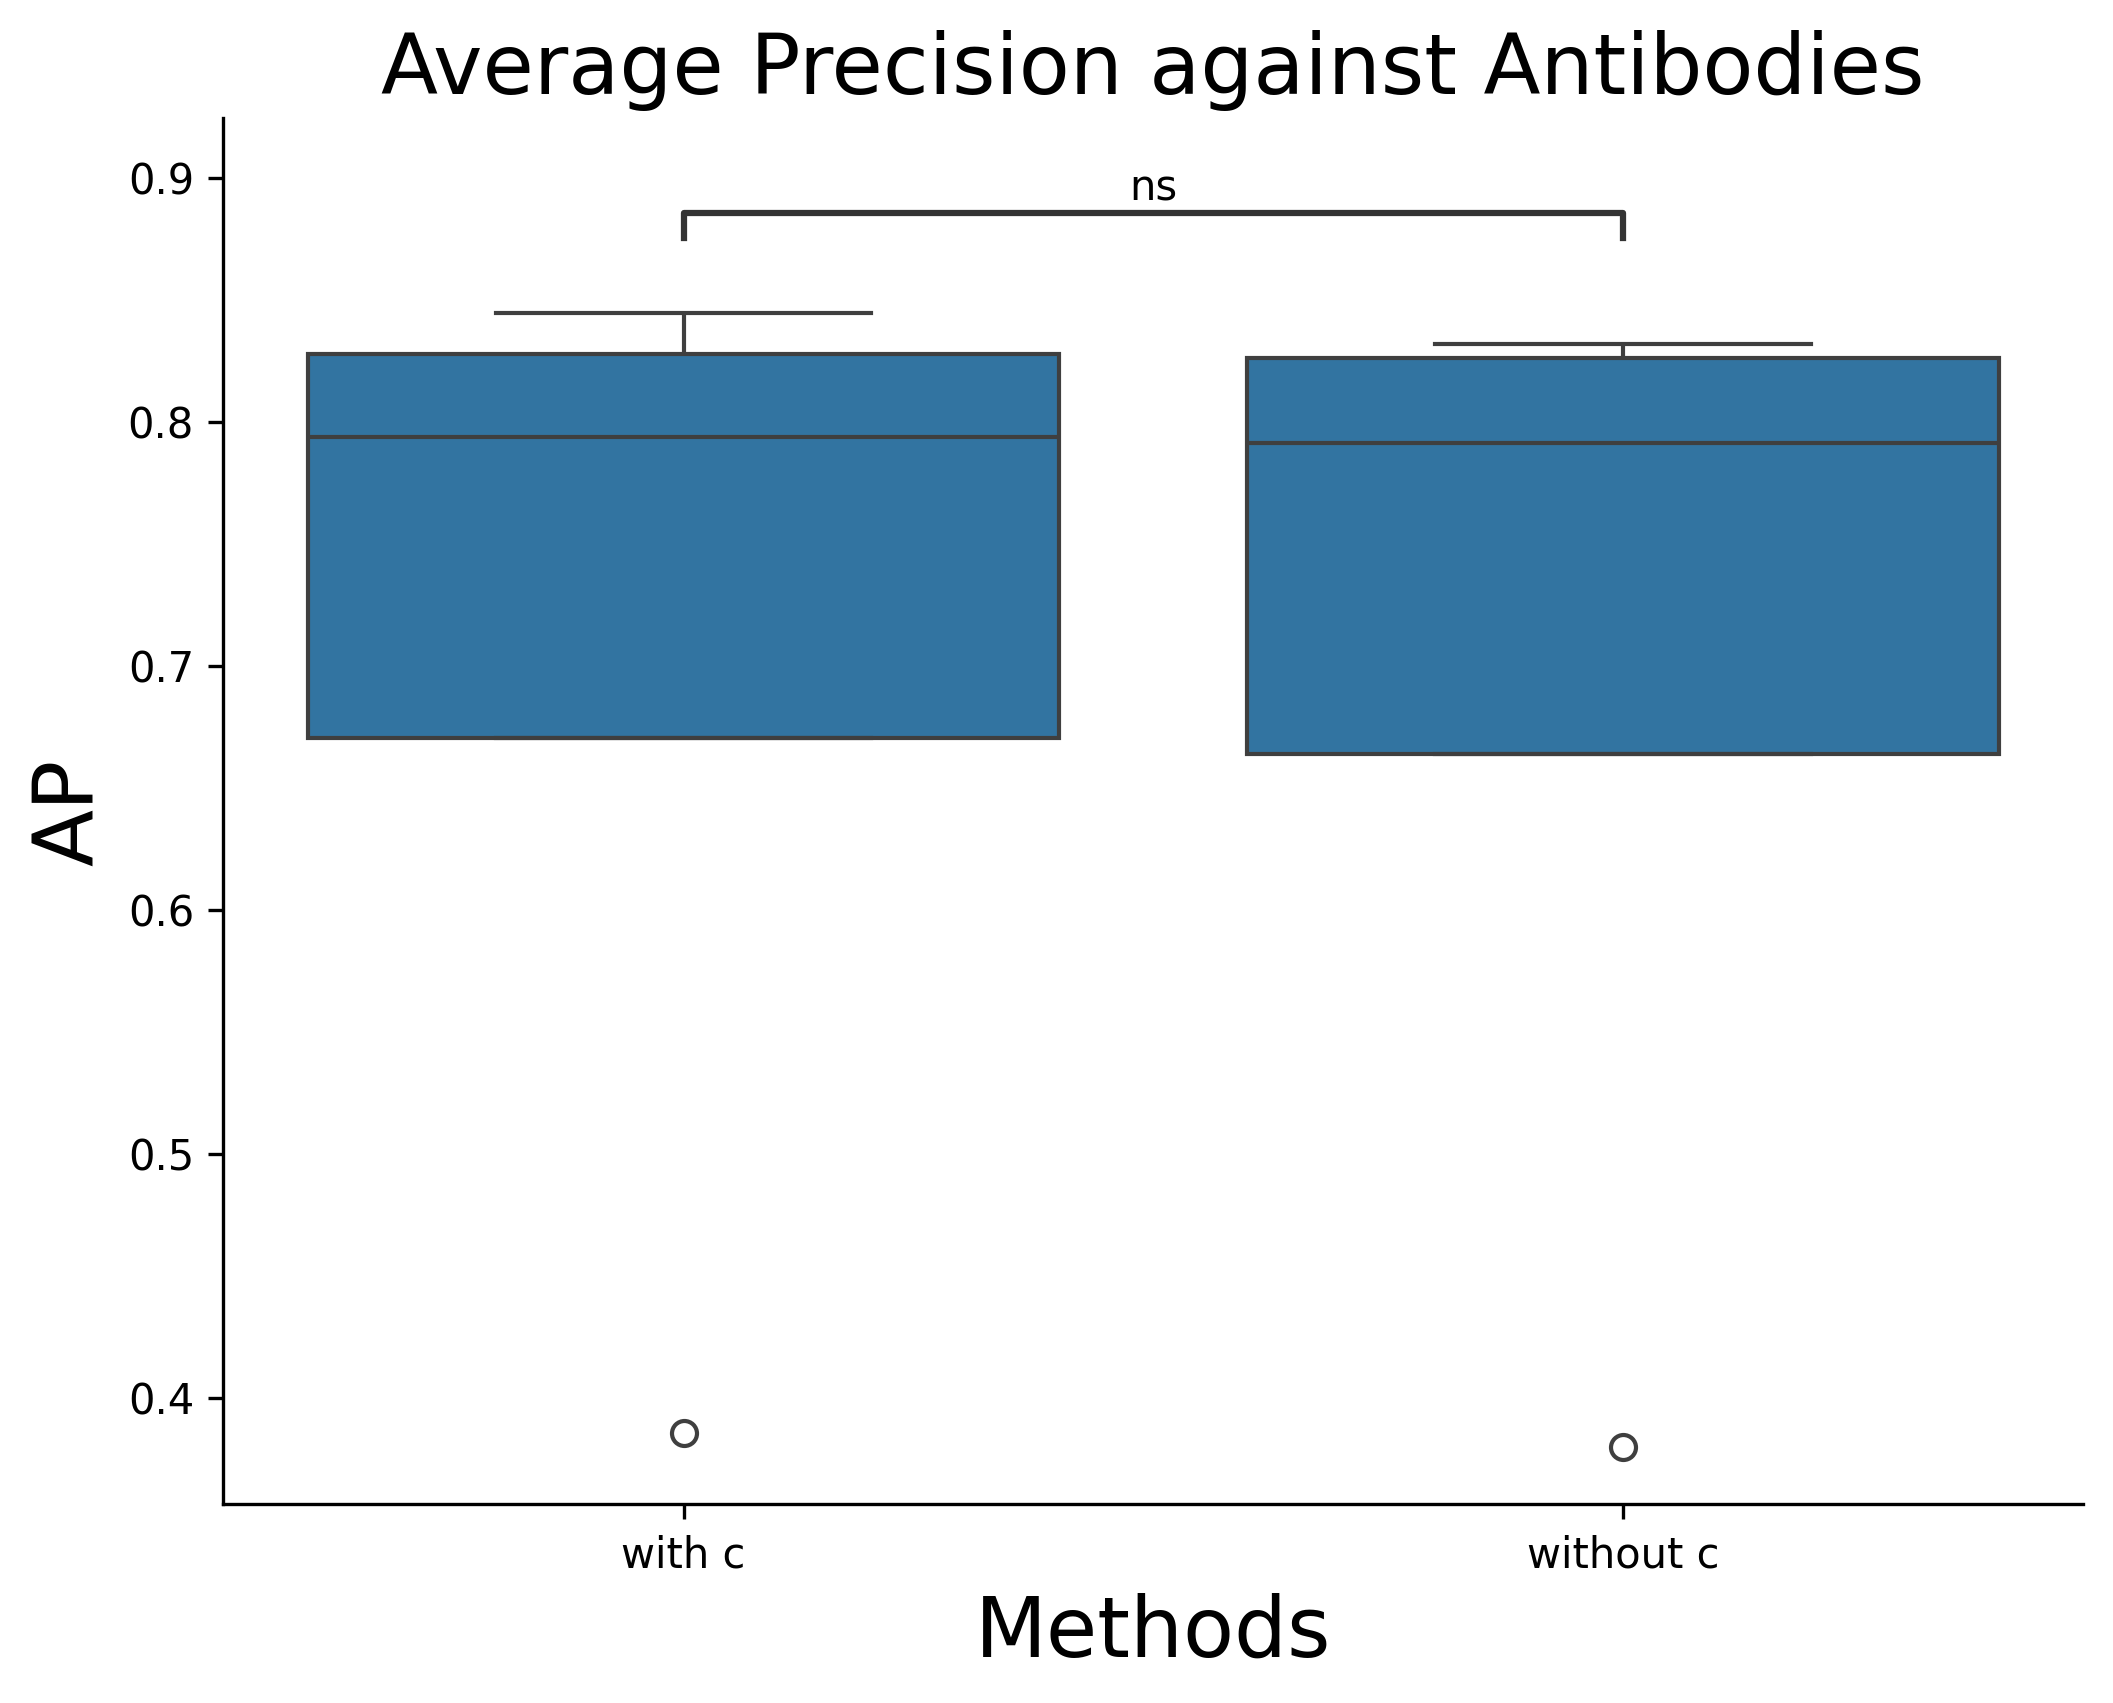

In [28]:
n_antibodies = ap_c.shape[0]
plot_df = pd.DataFrame({
    'AP': aps.flatten(),
    'Methods': np.repeat(methods, n_antibodies),
})

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
sns.boxplot(plot_df, x='Methods', y='AP', ax=ax)
ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('Methods', fontsize=20)
ax.set_ylabel('AP', fontsize=20)
ax.set_title('Average Precision against Antibodies', fontsize=20)

pairs=[("with c", "without c")]
annotator = Annotator(ax, pairs, data=plot_df, x="Methods", y="AP")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.show()

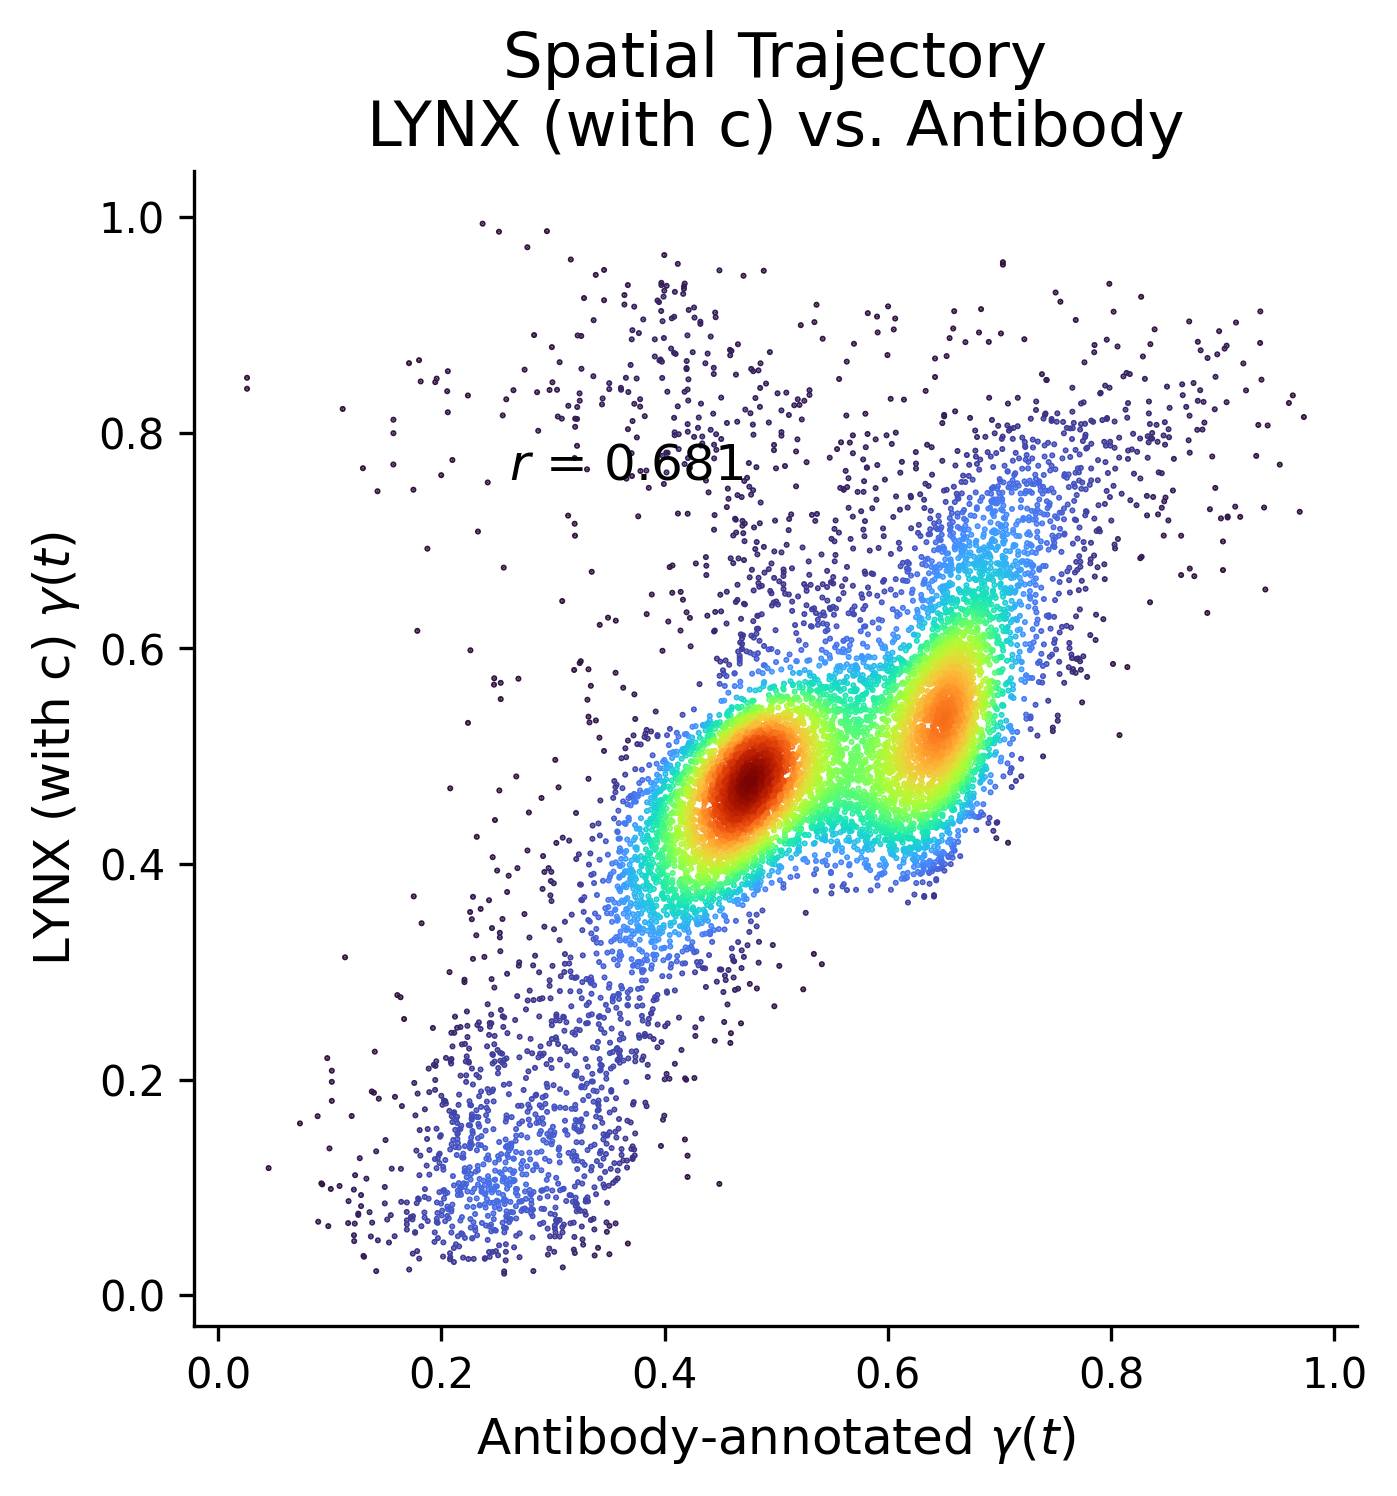

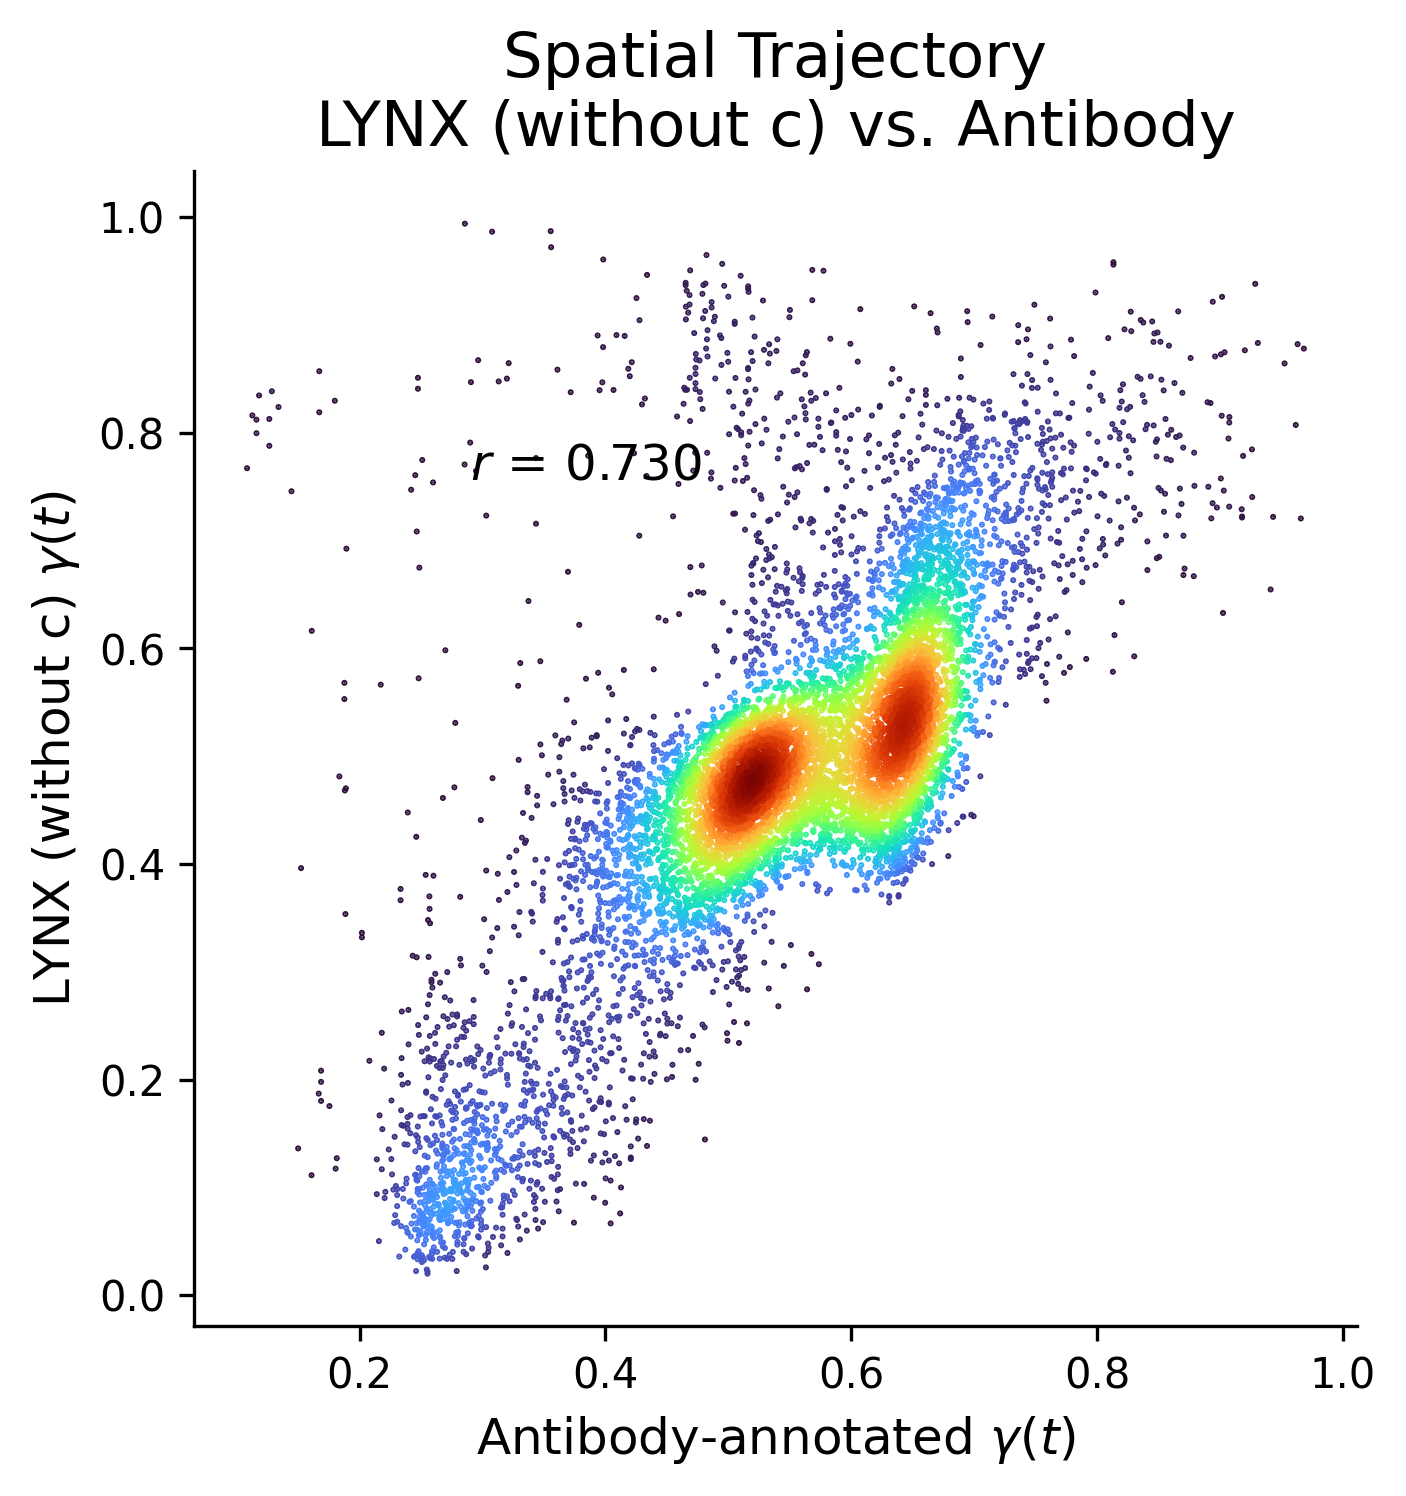

In [16]:
# Benchmark among ablations
rand_indices = np.random.choice(
    np.arange(adata_xenium.shape[0]), 10000, replace=False
)

plot.disp_kde_scatter(
    adata_xenium_c.obs['t'].values[rand_indices], adata_ab.obs['t'].values[rand_indices],
    xlabel=r"Antibody-annotated $\gamma(t)$",
    ylabel=r"LYNX (with c) $\gamma(t)$",
    title="Spatial Trajectory\nLYNX (with c) vs. Antibody"
)

plot.disp_kde_scatter(
    adata_xenium_nc.obs['t'].values[rand_indices], adata_ab.obs['t'].values[rand_indices],
    xlabel=r"Antibody-annotated $\gamma(t)$",
    ylabel=r"LYNX (without c) $\gamma(t)$",
    title="Spatial Trajectory\nLYNX (without c) vs. Antibody"
)

### cell-type interactions

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
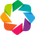

In [11]:
import holoviews as hv
hv.extension('bokeh')

def plot_celltype_interaction(attn_df, amplitude=1):
    assert np.array_equal(attn_df.index, attn_df.columns)
    attn_score = attn_df.values
    cell_types = attn_df.columns

    graph = hv.Graph([
        (cell_types[i], cell_types[j], attn_score[i, j])
        for i in range(len(cell_types)-1) for j in range(i+1, len(cell_types))
    ], vdims=['weight'])
    labels = hv.Labels(graph.nodes, ['x', 'y'], 'index')

    graph = graph.opts(
        node_color='index', edge_color=hv.dim('weight')*amplitude, cmap='Category10',
        edge_cmap='Reds', edge_line_width=hv.dim('weight')*amplitude,
    )
    graph = (graph * labels.opts(text_font_size='10pt', text_color='black'))

    return graph

In [12]:
# Helper functions
def build_celltype_attention(
    adata_subset,
    categories,
    attn_key='v_attn',
    celltype_key='cell_type',
    agg='mean',
    normalize=False
):
    """
    Parameters
    ----------
    adata_subset : AnnData
        The subset of the full data.
    attn_key : str
        Key in adata_subset.obsm storing the attention matrix (n_cells x n_clusters).
    celltype_key : str
        The obs field containing the raw cell type strings for each cell.
    agg : str or callable
        Aggregation function for grouping by cell type. E.g., 'mean', 'sum', etc.
    normalize : boolean
        Whether to use Laplacian normalization

    Returns
    -------
    pd.DataFrame
        DataFrame of shape (#full_celltypes, #full_celltypes) with the cell types
        as both row and column labels.
    """

    row_labels = adata_subset.obs[celltype_key].values

    # Retrieve the attention matrix.
    attn_matrix = adata_subset.obsm[attn_key]

    # Build a DataFrame: rows are the "target" cell types (raw strings)
    # and columns correspond to the factorized cell type labels.
    df = pd.DataFrame(
        data=attn_matrix,
        index=row_labels,
        columns=categories,
    )

    # Aggregate attention values by the target cell type.
    df_agg = df.groupby(level=0).agg(agg)

    intersection = df_agg.index.intersection(categories)
    df_agg = df_agg.loc[intersection]
    df_agg = df_agg[df_agg.index]

    # Symmetrize the matrix by adding its transpose.
    df_agg = df_agg.add(df_agg.T, fill_value=0)

    # Normalize rows by their sums.
    row_sums = df_agg.sum(axis=1).replace(0, np.nan)
    M = df_agg.values
    d_inv_sqrt = 1.0 / np.sqrt(row_sums.values)  # shape: (#celltypes,)
    # Outer product scaling: M_norm[i,j] = M[i,j] / sqrt(rowSum[i]*rowSum[j])
    M_norm = d_inv_sqrt[:, None] * M * d_inv_sqrt[None, :]

    # Return the final DataFrame with full_categories as both index and columns.
    df = pd.DataFrame(M_norm if normalize else M, index=df_agg.index, columns=df_agg.columns)

    df.loc[(df!=0).any(axis=1)]
    
    return df


def get_binned_attention_by_celltype(adata, celltype_categories, n_bins=50):
   
    # Get the pseudotime values.
    t_vals = adata.obs['t']

    # Build a DataFrame from the attention matrix with columns as the cell type labels.
    attn_df = pd.DataFrame(
        data=adata.obsm['v_attn'],
        index=adata.obs.index,
        columns=celltype_categories
    )
    # Add pseudotime to the DataFrame.
    attn_df['t'] = t_vals

    # Convert to long format: each row corresponds to one cell and one attended cell type.
    df_long = attn_df.melt(
        id_vars='t',
        value_vars=celltype_categories,
        var_name='cell_type',
        value_name='attn'
    )

    # Sort by pseudotime.
    df_long.sort_values(by='t', inplace=True)

    # Create a 'bin' column by binning pseudotime into quantile bins.
    df_long['bin'] = pd.qcut(df_long['t'], q=n_bins, labels=False)

    # Group by 'bin' and 'cell_type' to compute the average attention in each bin.
    grouped = df_long.groupby(['bin', 'cell_type']).agg({
        'attn': 'mean',
        't': 'mean'  # optionally, keep the average pseudotime for plotting
    }).reset_index()

    return grouped

/var/tmp/ipykernel_8422/2234972768.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=0).agg(agg)


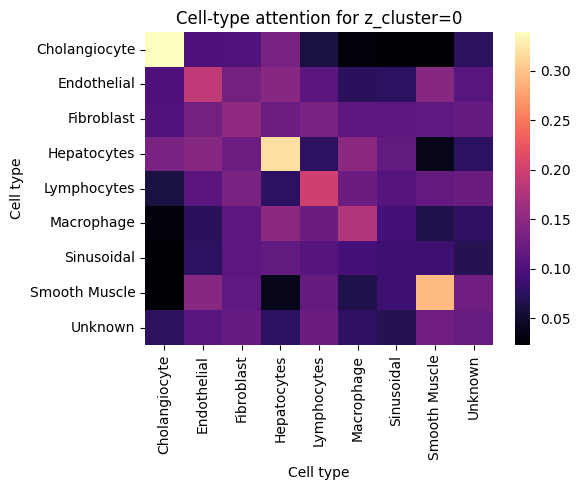

/var/tmp/ipykernel_8422/2234972768.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=0).agg(agg)


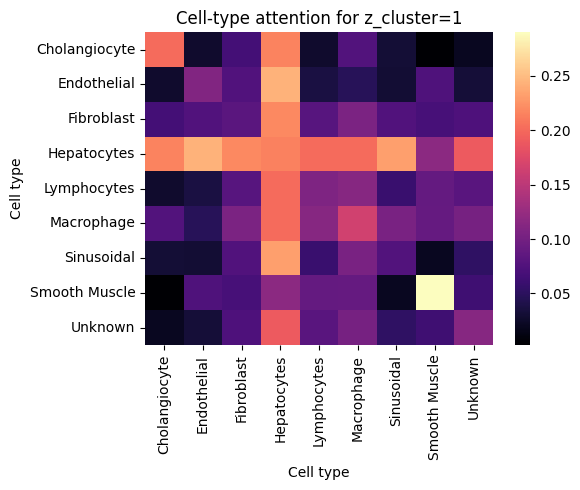

/var/tmp/ipykernel_8422/2234972768.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=0).agg(agg)


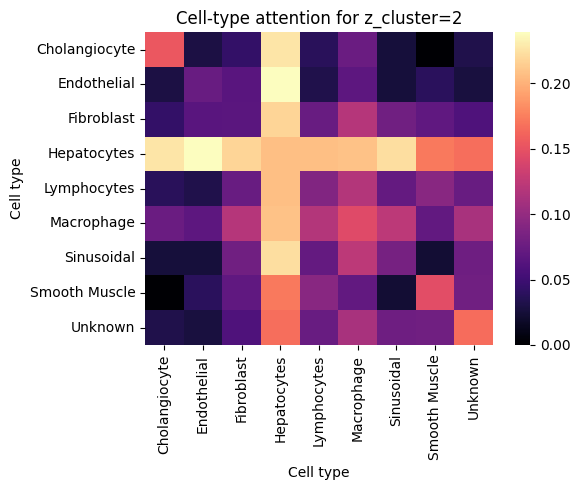

/var/tmp/ipykernel_8422/2234972768.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=0).agg(agg)


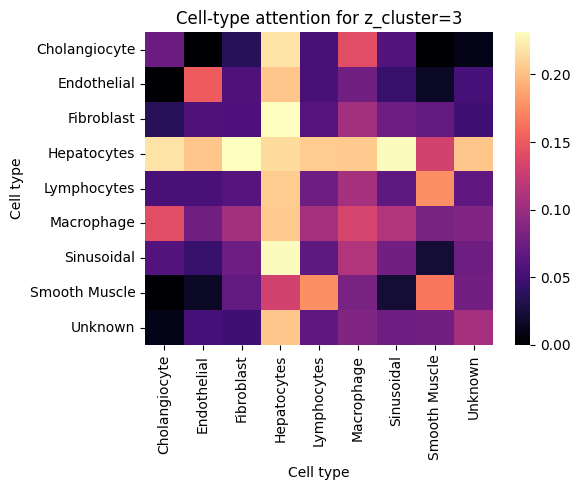

/var/tmp/ipykernel_8422/2234972768.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=0).agg(agg)


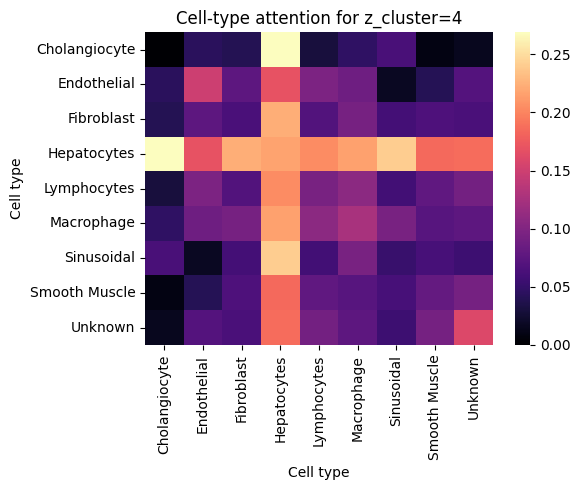

In [14]:
attn_dfs = []
attn_graphs = []

for cluster_id in sorted(adata_xenium_c.obs['zone'].unique()):
    adata_sub = adata_xenium_c[adata_xenium_c.obs['zone'] == cluster_id].copy()
    zone_attn_df = build_celltype_attention(
        adata_subset=adata_sub,
        attn_key='v_attn',
        celltype_key='cell_type',
        categories=categories,
        agg='mean',
        normalize=True
    )
    attn_dfs.append(zone_attn_df)

    plt.figure(figsize=(6,5))
    sns.heatmap(zone_attn_df, cmap='magma')
    plt.title(f"Cell-type attention for z_cluster={cluster_id}")
    plt.xlabel("Cell type")
    plt.ylabel("Cell type")
    plt.tight_layout()
    plt.show()

    attn_graph = plot_celltype_interaction(zone_attn_df, amplitude=50)
    attn_graphs.append(attn_graph)

In [15]:
holomap = hv.HoloMap({i: graph for i, graph in enumerate(attn_graphs)},  kdims='{}\nBin (PV->CV)'.format(sample_id))
holomap = holomap.opts(
    xaxis=None, yaxis=None, axiswise=True,
    width=500, height=500
) 

holomap

:HoloMap   [NIH_F5
Bin (PV->CV)]
   :Overlay
      .Graph.I  :Graph   [start,end]   (weight)
      .Labels.I :Labels   [x,y]   (index)

/var/tmp/ipykernel_8422/2234972768.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=0).agg(agg)


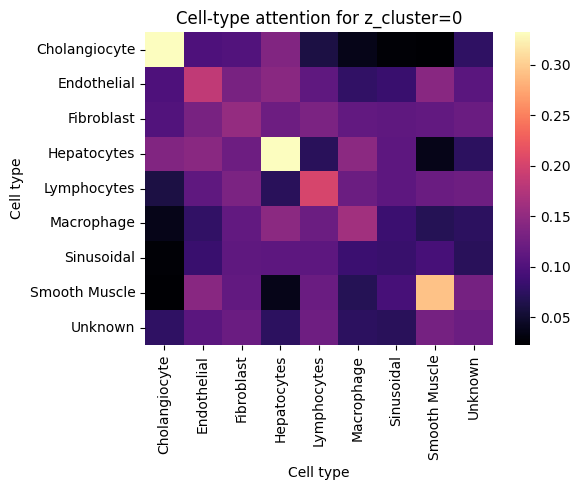

/var/tmp/ipykernel_8422/2234972768.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=0).agg(agg)


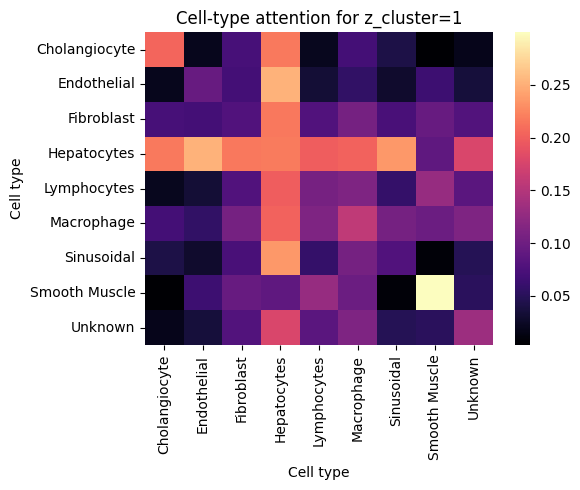

/var/tmp/ipykernel_8422/2234972768.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=0).agg(agg)


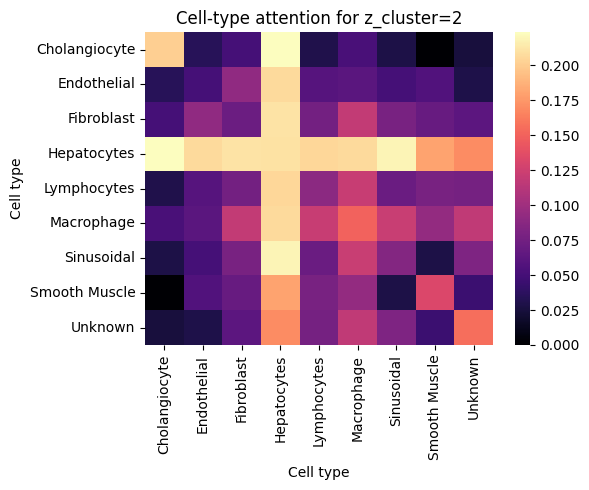

/var/tmp/ipykernel_8422/2234972768.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=0).agg(agg)


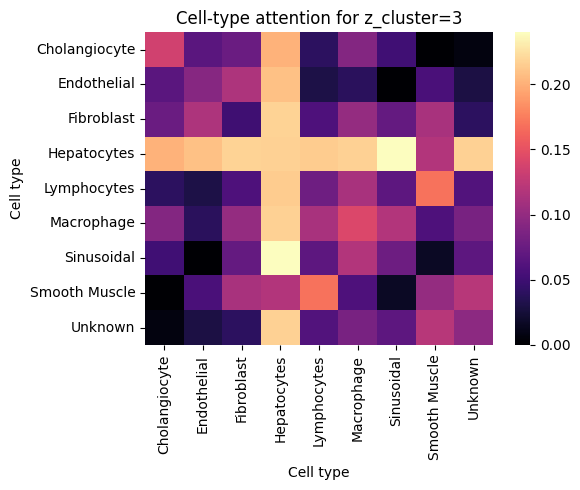

/var/tmp/ipykernel_8422/2234972768.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=0).agg(agg)


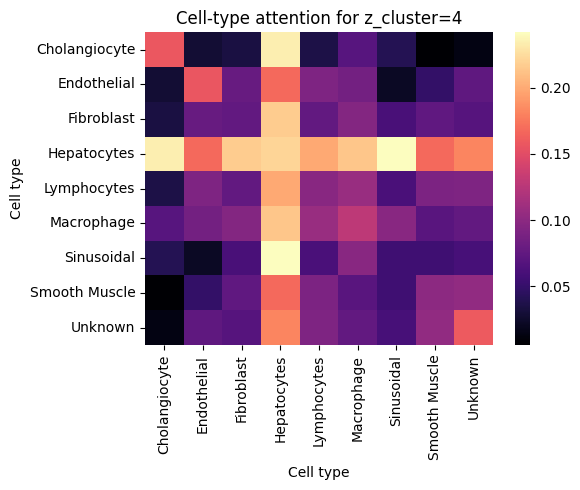

In [16]:
attn_dfs = []
attn_graphs = []

for cluster_id in sorted(adata_xenium_nc.obs['zone'].unique()):
    adata_sub = adata_xenium_nc[adata_xenium_nc.obs['zone'] == cluster_id].copy()
    zone_attn_df = build_celltype_attention(
        adata_subset=adata_sub,
        attn_key='v_attn',
        celltype_key='cell_type',
        categories=categories,
        agg='mean',
        normalize=True
    )
    attn_dfs.append(zone_attn_df)

    plt.figure(figsize=(6,5))
    sns.heatmap(zone_attn_df, cmap='magma')
    plt.title(f"Cell-type attention for z_cluster={cluster_id}")
    plt.xlabel("Cell type")
    plt.ylabel("Cell type")
    plt.tight_layout()
    plt.show()

    attn_graph = plot_celltype_interaction(zone_attn_df, amplitude=50)
    attn_graphs.append(attn_graph)

In [17]:
holomap = hv.HoloMap({i: graph for i, graph in enumerate(attn_graphs)},  kdims='{}\nBin (PV->CV)'.format(sample_id))
holomap = holomap.opts(
    xaxis=None, yaxis=None, axiswise=True,
    width=500, height=500
) 

holomap

:HoloMap   [NIH_F5
Bin (PV->CV)]
   :Overlay
      .Graph.I  :Graph   [start,end]   (weight)
      .Labels.I :Labels   [x,y]   (index)